# Frequency Offline Inference Comparison

Evaluate the 50Hz, 25Hz, and 10Hz models on one selected AB07 trial and plot all predictions on the same axes.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from frequency_inference_utils import (
    DATA_ROOT,
    MODEL_SPECS,
    hyperparam_config,
    load_frequency_model,
    load_trial_for_frequency,
    metric_pair,
    predict_series,
)

plt.rcParams["figure.figsize"] = (15, 4)
plt.rcParams["axes.grid"] = False

## Editable Settings

In [16]:
subject = "AB07_Leo"
speed = "1p2mps"
trial = "trial_3"
legs = ["R", "L"]
frequencies = ["50Hz", "25Hz", "10Hz"]

# Ground-truth label low-pass cutoff. This matches the AccelOnly/GyroOnly offline inference notebook.
label_cutoff_freq = 4.0

# Set to None for full plot, or use a tuple like (9.5, 14.0).
xlim = (9.5, 13.0)

batch_size = 1024
epoch = None
zero_0mps_labels = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trial_dir = DATA_ROOT / subject / speed / trial
print(device)
print(trial_dir)

cuda
/home/metamobility2/JiminMM2/Dataset/Biotorque_14Subjects/Synced_Biotorque_LG_Data/AB07_Leo/1p2mps/trial_3


## Load Models

In [17]:
selected_specs = {name: MODEL_SPECS[name] for name in frequencies}
models = {}

for freq_label, spec in selected_specs.items():
    models[freq_label] = load_frequency_model(
        spec["model_dir"],
        spec["model_name"],
        spec["target_frequency"],
        device,
        epoch=epoch,
    )


TCN parameter #:  292560

FCNN parameter #:  7601
Loaded IDL_Freq_50Hz: /home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_Frequency/IDL_Freq_50Hz/IDL_Freq_50Hz.pt

TCN parameter #:  292560

FCNN parameter #:  7601
Loaded IDL_Freq_25Hz: /home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_Frequency/IDL_Freq_25Hz/IDL_Freq_25Hz.pt

TCN parameter #:  292560

FCNN parameter #:  7601
Loaded IDL_Freq_10Hz: /home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_Frequency/IDL_Freq_10Hz/IDL_Freq_10Hz.pt


/home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_Frequency/frequency_inference_utils.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_fi

## Run Inference

In [18]:
results = {}
metrics_rows = []

for freq_label, spec in selected_specs.items():
    trial_data = load_trial_for_frequency(
        trial_dir,
        spec["model_dir"],
        spec["target_frequency"],
        label_cutoff_freq=label_cutoff_freq,
        zero_0mps_labels=zero_0mps_labels,
    )
    config = hyperparam_config(spec["target_frequency"], spec["model_name"])
    start_index = config["window_size"] - 1
    results[freq_label] = {}

    for leg in legs:
        input_tensor, label_raw = trial_data[leg]
        try:
            pred = predict_series(
                models[freq_label],
                input_tensor,
                spec["model_dir"],
                spec["target_frequency"],
                spec["model_name"],
                device,
                batch_size=batch_size,
            )
        except ValueError as exc:
            print(f"Skipping {freq_label} {leg}: {exc}")
            results[freq_label][leg] = None
            metrics_rows.append({
                "subject": subject,
                "speed": speed,
                "trial": trial,
                "frequency": freq_label,
                "target_frequency_hz": spec["target_frequency"],
                "leg": leg,
                "n_samples": 0,
                "rmse": np.nan,
                "r2": np.nan,
            })
            continue

        overlap = min(len(pred), len(label_raw[start_index:]))
        truth = label_raw[start_index:start_index + overlap]
        pred = pred[:overlap]
        time = np.arange(start_index, start_index + overlap) / spec["target_frequency"]
        rmse, r2 = metric_pair(truth, pred)

        results[freq_label][leg] = {
            "time": time,
            "truth": truth,
            "pred": pred,
            "rmse": rmse,
            "r2": r2,
        }
        metrics_rows.append({
            "subject": subject,
            "speed": speed,
            "trial": trial,
            "frequency": freq_label,
            "target_frequency_hz": spec["target_frequency"],
            "leg": leg,
            "n_samples": len(truth),
            "rmse": rmse,
            "r2": r2,
        })

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

,subject,speed,trial,frequency,target_frequency_hz,leg,n_samples,rmse,r2
0,AB07_Leo,1p2mps,trial_3,50Hz,50,R,1356,0.097876,0.909377
1,AB07_Leo,1p2mps,trial_3,50Hz,50,L,1356,0.100870,0.879883
2,AB07_Leo,1p2mps,trial_3,25Hz,25,R,631,0.103439,0.898888
3,AB07_Leo,1p2mps,trial_3,25Hz,25,L,631,0.096618,0.888798
4,AB07_Leo,1p2mps,trial_3,10Hz,10,R,196,0.106743,0.887719
5,AB07_Leo,1p2mps,trial_3,10Hz,10,L,196,0.127475,0.803760


## Plot

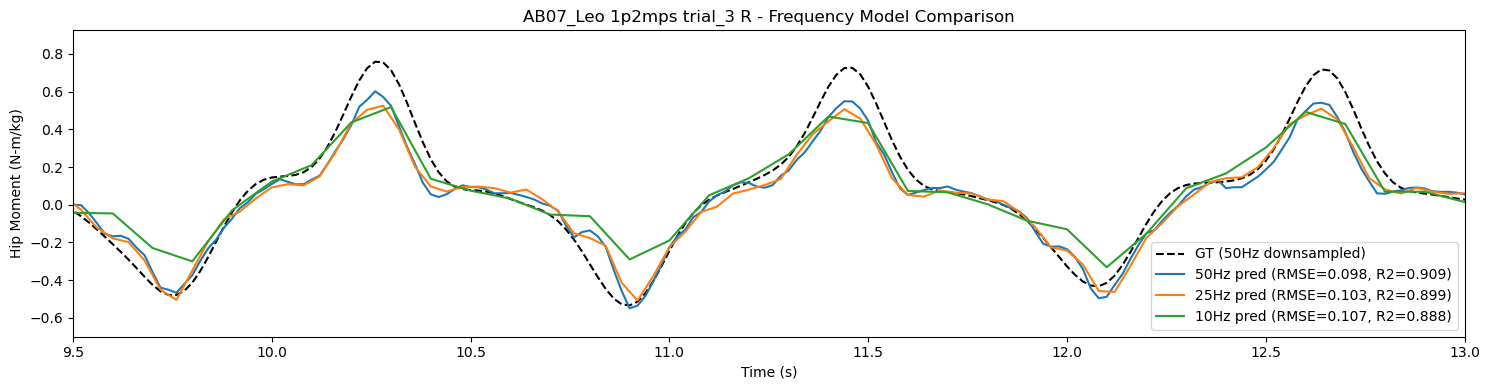

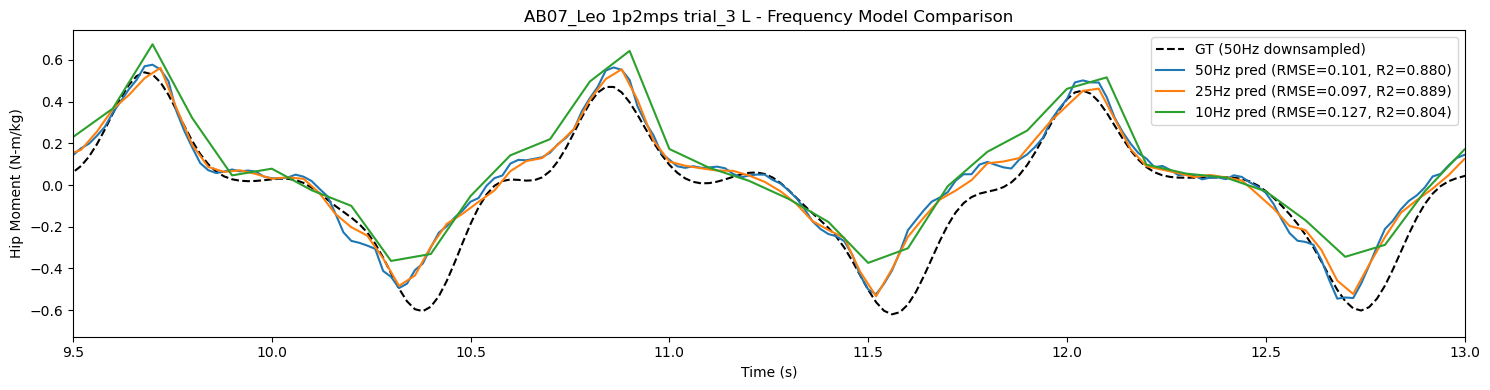

In [21]:
colors = {"50Hz": "tab:blue", "25Hz": "tab:orange", "10Hz": "tab:green"}

for leg in legs:
    available = [freq for freq in frequencies if results[freq].get(leg) is not None]
    if not available:
        print(f"No predictions available for {leg}")
        continue

    highest_freq = max(available, key=lambda freq: MODEL_SPECS[freq]["target_frequency"])
    gt = results[highest_freq][leg]

    plt.figure(figsize=(15, 4))
    plt.plot(gt["time"], gt["truth"], "--", color="black", linewidth=1.5, label=f"GT ({highest_freq} downsampled)")

    for freq in available:
        item = results[freq][leg]
        label = f"{freq} pred (RMSE={item['rmse']:.3f}, R2={item['r2']:.3f})"
        plt.plot(item["time"], item["pred"], color=colors.get(freq), label=label)

    if xlim is not None:
        plt.xlim(*xlim)
    plt.xlabel("Time (s)")
    plt.ylabel("Hip Moment (N-m/kg)")
    plt.title(f"{subject} {speed} {trial} {leg} - Frequency Model Comparison")
    plt.legend()
    plt.savefig(f"{subject}_{speed}_{trial}_{leg}_frequency_comparison.svg", format="svg")
    plt.tight_layout()
    
    plt.show()

## Optional Save

In [ ]:
save_outputs = False
output_dir = Path("/home/metamobility2/JiminMM2/IDL Project/Jimin_IDL_Frequency")

if save_outputs:
    output_dir.mkdir(parents=True, exist_ok=True)
    metrics_path = output_dir / f"{subject}_{speed}_{trial}_frequency_trial_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False)
    print(metrics_path)